In [1]:
import torch
import torchvision
from torch import nn
from torchvision import models
import rootutils
from torchvision.transforms import v2
from sklearn.model_selection import StratifiedKFold
import sklearn
import tqdm
import numpy as np

In [ ]:
rootutils.setup_root(".", indicator=".project-root", pythonpath=True)
from data.components.transform_subset import TransformSubset

In [3]:
class EfficientNetBaseline(nn.Module):
    def __init__(self, num_classes: int, pretrained: bool = True) -> None:
        """Initialize EfficientNetBaseline.

        :param num_classes: Number of output classes.
        :param pretrained: Whether to use pretrained ImageNet weights. Defaults to True.
        """
        super().__init__()

        if pretrained:
            self.model = models.efficientnet_b0(
                weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
            )
        else:
            self.model = models.efficientnet_b0(weights=None)

        # Replace classifier head
        num_ftrs = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(num_ftrs, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

In [4]:
train_transforms = v2.Compose(
    [
        v2.Resize((640, 480), antialias=True),
        v2.RandomHorizontalFlip(),
        v2.RandomVerticalFlip(),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)
test_transforms = v2.Compose(
    [
        v2.Resize((640, 480), antialias=True),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [5]:
device = torch.device("cuda", index=0)
torch.set_float32_matmul_precision("high")

scaler = torch.amp.GradScaler('cuda')

In [6]:
data_path = "../data/surface/train"
dataset = torchvision.datasets.ImageFolder(root=data_path)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

class_counts = np.unique(dataset.targets, return_counts=True)[1]
weights = 1.0 / torch.tensor(class_counts, dtype=torch.float32)
weights = weights / weights.sum()

In [7]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from torchmetrics import MeanMetric

/home/lukasb/miniforge3/envs/defect-detection/lib/python3.10/site-packages/torchmetrics/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


In [8]:
EPOCHS = 40

In [10]:
embedding_list = []
pred_prob_list = []
embeddings_model = None

for fold, (train_idx, val_idx) in enumerate(skf.split(dataset.samples, dataset.targets)):
    train_subset = TransformSubset(
        dataset,
        train_idx,
        transform=train_transforms
    )
    train_dataloader = torch.utils.data.DataLoader(
        train_subset, 
        batch_size=32,
        shuffle=True, 
        num_workers=8,
        pin_memory=True,
        persistent_workers=True)  

    num_classes = len(dataset.classes)
    model = EfficientNetBaseline(num_classes=num_classes, pretrained=True)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=weights.to(device))
    criterion = criterion.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

    train_acc = MulticlassAccuracy(num_classes=num_classes, average="weighted").to(device)
    train_f1 = MulticlassF1Score(num_classes=num_classes, average="weighted").to(device)
    train_loss = MeanMetric().to(device)

    for epoch in range(EPOCHS):
        model.train()
        train_acc.reset()
        train_f1.reset()
        train_loss.reset()

        # Add leave=False to clear progress bar after completion
        pbar = tqdm.tqdm(train_dataloader, desc=f"Fold {fold}, Epoch {epoch}", leave=False, position=0)
        for images, labels in pbar:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad(set_to_none=True)
            
            # Mixed precision training
            with torch.amp.autocast('cuda'):
                logits = model(images)
                loss = criterion(logits, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            scheduler.step()

            with torch.no_grad():
                preds = torch.argmax(logits, dim=1)
                train_acc.update(preds, labels)
                train_f1.update(preds, labels)
                train_loss.update(loss.item())
            
    print(f"Fold {fold}, Epoch {epoch} - Train Loss: {train_loss.compute():.4f}, Train Acc: {train_acc.compute():.4f}, Train F1: {train_f1.compute():.4f}")

    val_subset = TransformSubset(
        dataset,
        val_idx,
        transform=test_transforms
    )
    val_dataloader = torch.utils.data.DataLoader(
        val_subset,
        batch_size=64,
        shuffle=False, 
        num_workers=8,
        pin_memory=True,
        persistent_workers=True
    )

    model.eval()
    with torch.no_grad():
        if embeddings_model is None:
            embeddings_model = model
        for images, labels in tqdm.tqdm(val_dataloader, desc=f"Fold {fold} Calculate embeddings", leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            pred_prob = torch.softmax(logits, dim=1)
            pred_prob_list.append(pred_prob.cpu())
           
            embeddings = embeddings_model.model.features(images)
            embeddings = embeddings_model.model.avgpool(embeddings)
            embeddings = torch.flatten(embeddings, 1)
            embedding_list.append(embeddings.cpu())
    

embeddings = torch.vstack(embedding_list)
pred_probs = torch.vstack(pred_prob_list)

Fold 0, Epoch 39 - Train Loss: 0.0430, Train Acc: 0.9732, Train F1: 0.9732


Fold 1, Epoch 39 - Train Loss: 0.0509, Train Acc: 0.9682, Train F1: 0.9683


Fold 2, Epoch 39 - Train Loss: 0.0590, Train Acc: 0.9651, Train F1: 0.9652


Fold 3, Epoch 39 - Train Loss: 0.0639, Train Acc: 0.9669, Train F1: 0.9670


Fold 4, Epoch 39 - Train Loss: 0.0540, Train Acc: 0.9718, Train F1: 0.9719


In [11]:
from cleanlab import Datalab
import pandas as pd

filepaths = [path for path, _ in dataset.samples]
labels = np.array([label for _, label in dataset.samples])

# Create pandas DataFrame (cleanlab works better with DataFrames)
data = pd.DataFrame({
    "image": filepaths,
    "label": labels,
})

/home/lukasb/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [12]:
print(embeddings.size())
print(pred_probs.size())

torch.Size([5588, 1280])
torch.Size([5588, 12])


In [13]:
# Create Datalab instance
lab = Datalab(data=data, label_name="label", task="classification")

In [14]:
lab.find_issues(features=embeddings.numpy(), pred_probs=pred_probs.numpy())

Finding null issues ...
Finding label issues ...
Finding outlier issues ...
Finding outlier issues ...
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 4466 issues found in the dataset.
Finding near_duplicate issues ...
Finding non_iid issues ...
Finding class_imbalance issues ...
Finding underperforming_group issues ...

Audit complete. 4466 issues found in the dataset.


In [15]:
lab.report()

Dataset Information: num_examples: 5588, num_classes: 12

Here is a summary of various issues found in your data:

           issue_type  num_issues
                label        4151
       near_duplicate         134
underperforming_group          87
              outlier          57
      class_imbalance          36
              non_iid           1

Learn about each issue: https://docs.cleanlab.ai/stable/cleanlab/datalab/guide/issue_type_description.html
See which examples in your dataset exhibit each issue via: `datalab.get_issues(<ISSUE_NAME>)`

Data indices corresponding to top examples of each issue are shown below.


----------------------- label issues -----------------------

About this issue:
	Examples whose given label is estimated to be potentially incorrect
    (e.g. due to annotation error) are flagged as having label issues.
    

Number of examples with this issue: 4151
Overall dataset quality in terms of this issue: 0.2387

Examples representing most severe instances o

In [16]:
label_issues = lab.get_issues("label")
label_issues_df = label_issues.query("is_label_issue").sort_values("label_score")
label_issues_df.head()

,is_label_issue,label_score,given_label,predicted_label
116,True,1.491408e-13,0,1
117,True,7.915424e-12,0,1
115,True,1.061816e-11,0,1
118,True,1.147798e-11,0,1
4596,True,1.027868e-10,7,2


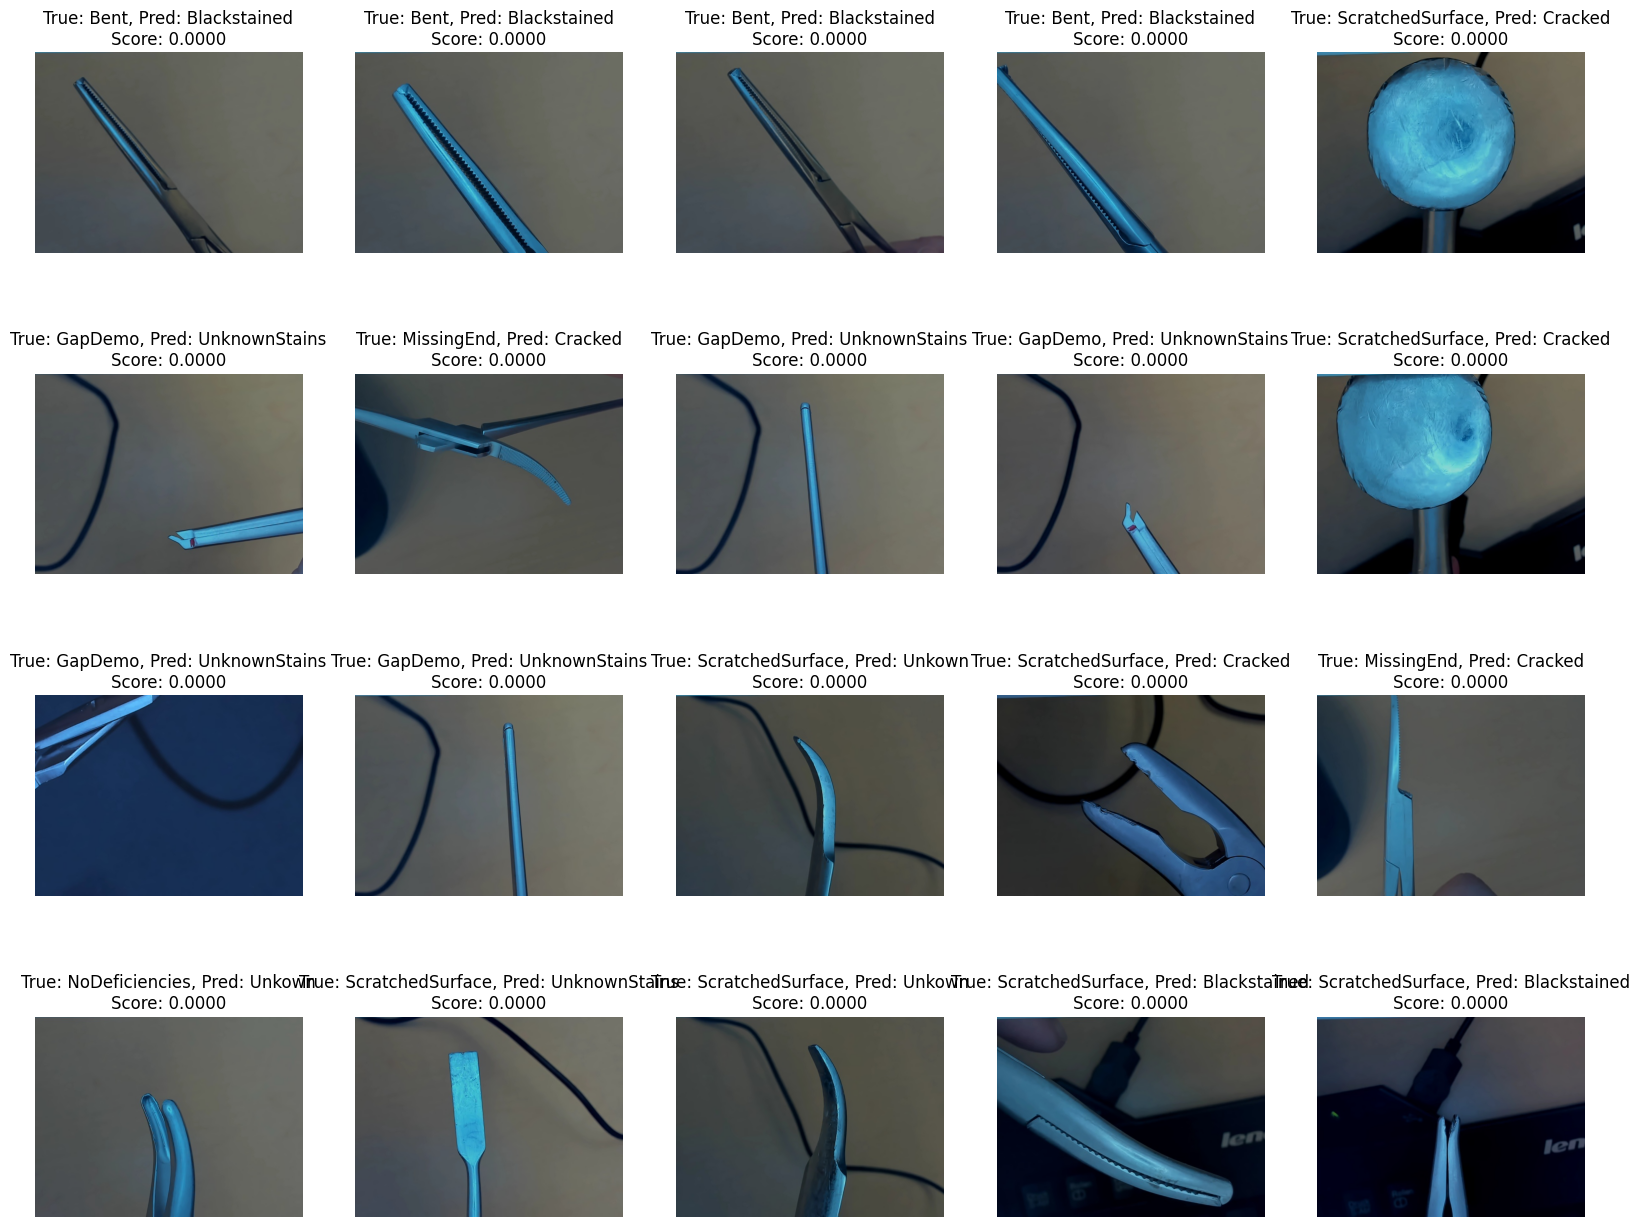

In [17]:
import matplotlib.pyplot as plt
from PIL import Image

# Get the top 20 mislabeled images
top_mislabeled = label_issues_df.head(20)

# Create a figure with 4 rows and 5 columns
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, (i, row) in enumerate(top_mislabeled.iterrows()):
    imd_id = row.name
    true_label_id = row['given_label']
    predicted_label_id = row['predicted_label']
    label_score = row['label_score']

    img_path = data.loc[imd_id, 'image']
    true_label = dataset.classes[true_label_id]
    predicted_label = dataset.classes[predicted_label_id]

    # Load and display the image
    img = Image.open(img_path).convert("RGB")
    axes[idx].imshow(img)
    axes[idx].set_title(f"True: {true_label}, Pred: {predicted_label}\nScore: {label_score:.4f}")
    axes[idx].axis('off')

In [20]:
near_duplicates = lab.get_issues("near_duplicate").query("is_near_duplicate_issue").sort_values("near_duplicate_score", ascending=True)
near_duplicates.head()

,is_near_duplicate_issue,near_duplicate_score,near_duplicate_sets,distance_to_nearest_neighbor
5276,True,0.0,[2174],0.0
4407,True,0.0,[4707],0.0
4406,True,0.0,[3498],0.0
4405,True,0.0,[140],0.0
4172,True,0.0,[5530],0.0


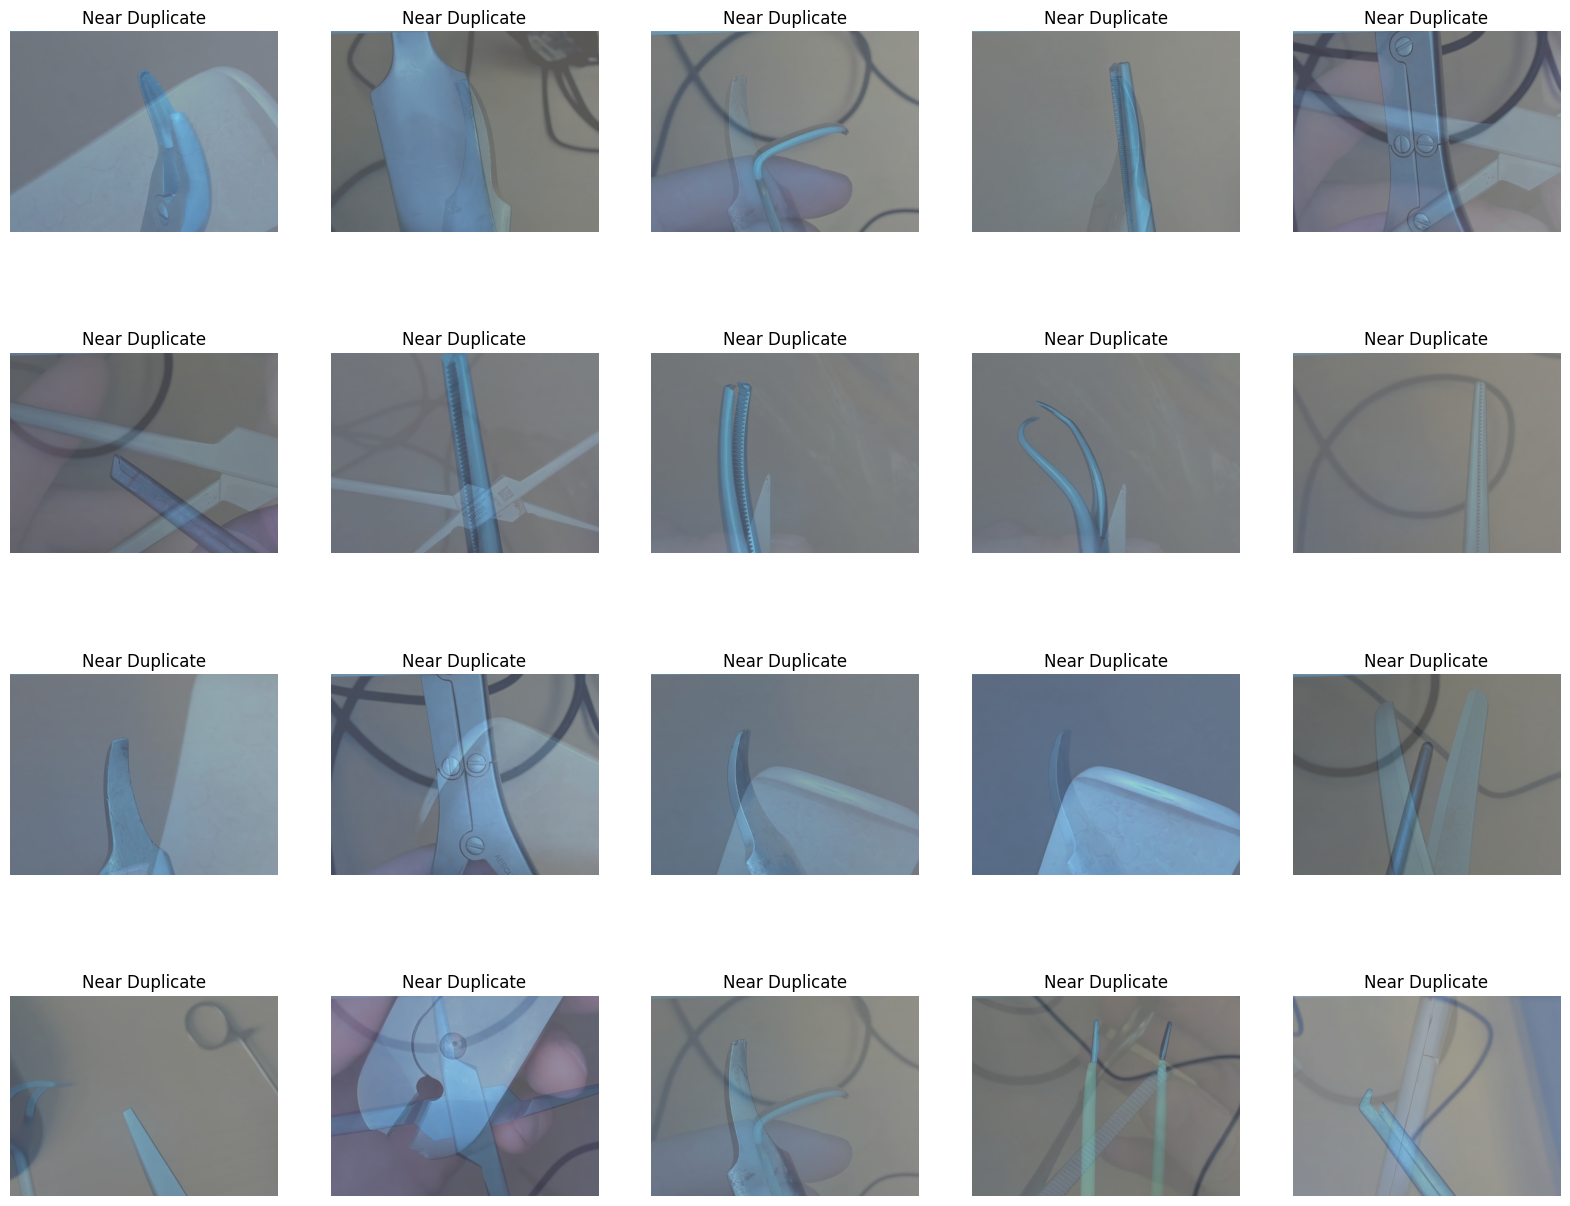

In [21]:
top_near_duplicates = near_duplicates.head(20)

# Create a figure with 4 rows and 5 columns
fig, axes = plt.subplots(4, 5, figsize=(20, 16))
axes = axes.flatten()

for idx, (i, row) in enumerate(top_near_duplicates.iterrows()):
    imd_id = row.name
    near_neighbor_id = row['near_duplicate_sets'][0]

    img_path = data.loc[imd_id, 'image']
    neighbor_img_path = data.loc[near_neighbor_id, 'image']

    # Load and display the image
    img = Image.open(img_path).convert("RGB")
    neighbor_img = Image.open(neighbor_img_path).convert("RGB")
    axes[idx].imshow(img, alpha=0.5)
    axes[idx].imshow(neighbor_img, alpha=0.5)
    axes[idx].set_title(f"Near Duplicate")
    axes[idx].axis('off')